2025-05-20 08:40:48.309346: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1747744848.326804 2299784 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1747744848.332186 2299784 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1747744848.345590 2299784 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747744848.345610 2299784 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1747744848.345611 2299784 computation_placer.cc:177] computation placer alr

🔍 Image ID: 10019047332195527319842144727711173804 (Cancer)


I0000 00:00:1747744864.698627 2299964 service.cc:152] XLA service 0x7f22ec001d40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1747744864.698673 2299964 service.cc:160]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2025-05-20 08:41:04.729500: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1747744864.904007 2299964 cuda_dnn.cc:529] Loaded cuDNN version 90300


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step


I0000 00:00:1747744868.281492 2299964 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


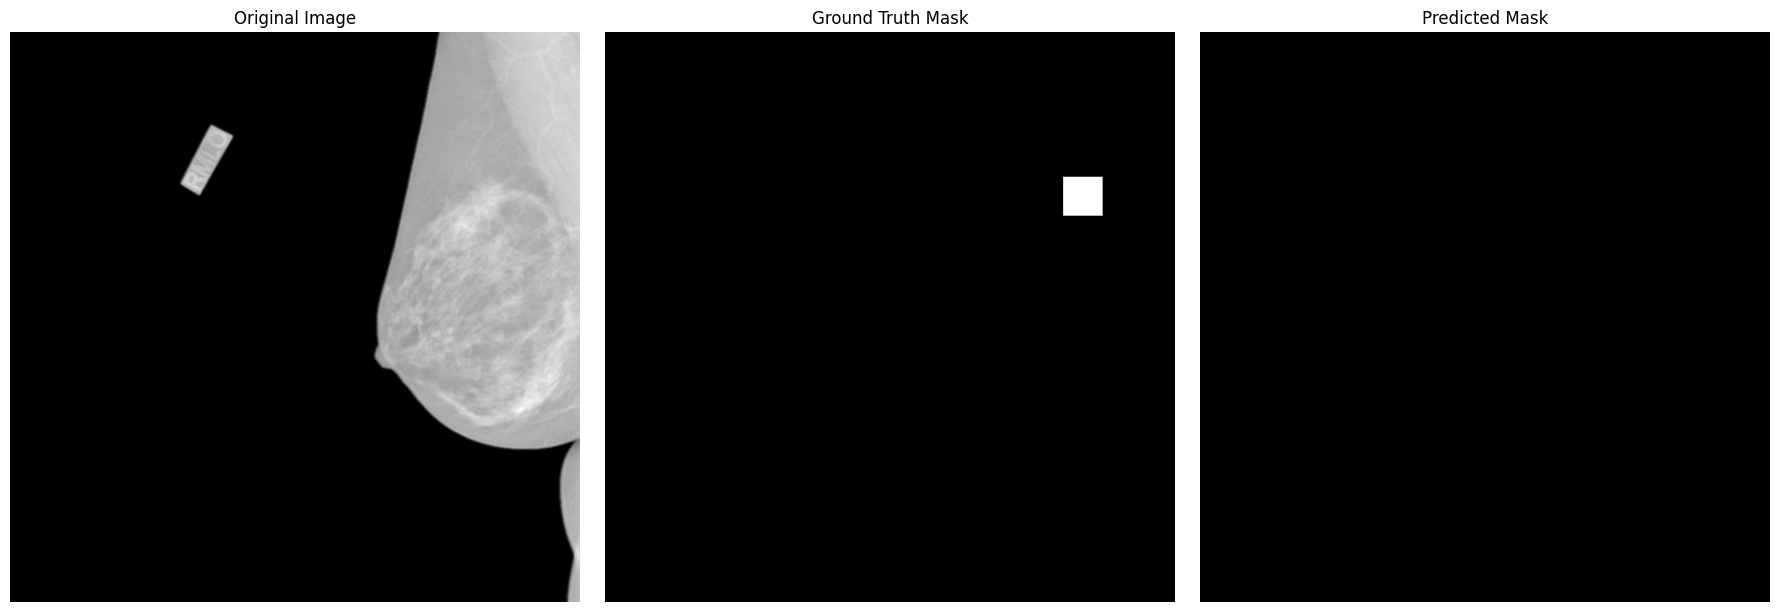

🔍 Image ID: 100310444385559225227798287808596450771 (Cancer)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


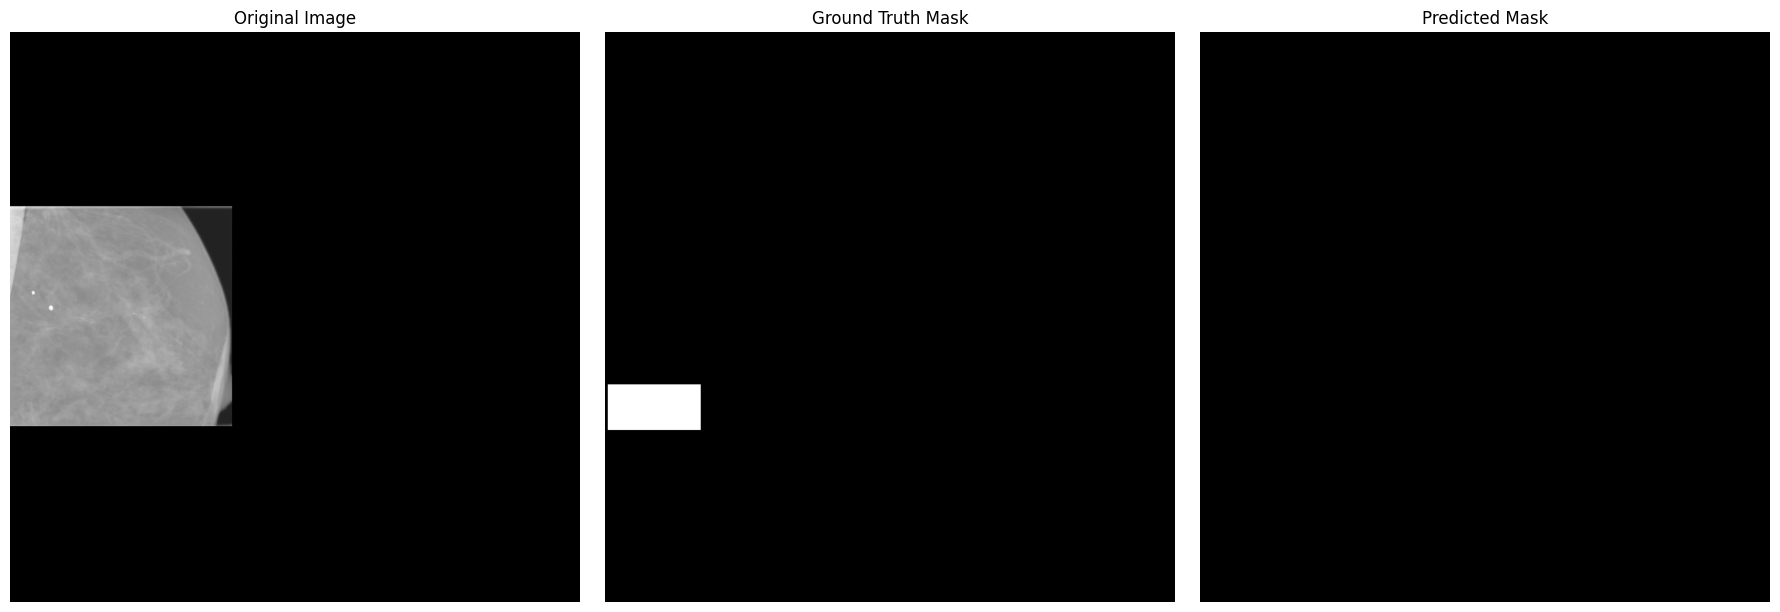

🔍 Image ID: 100388357645234274547518855405737568418 (Cancer)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


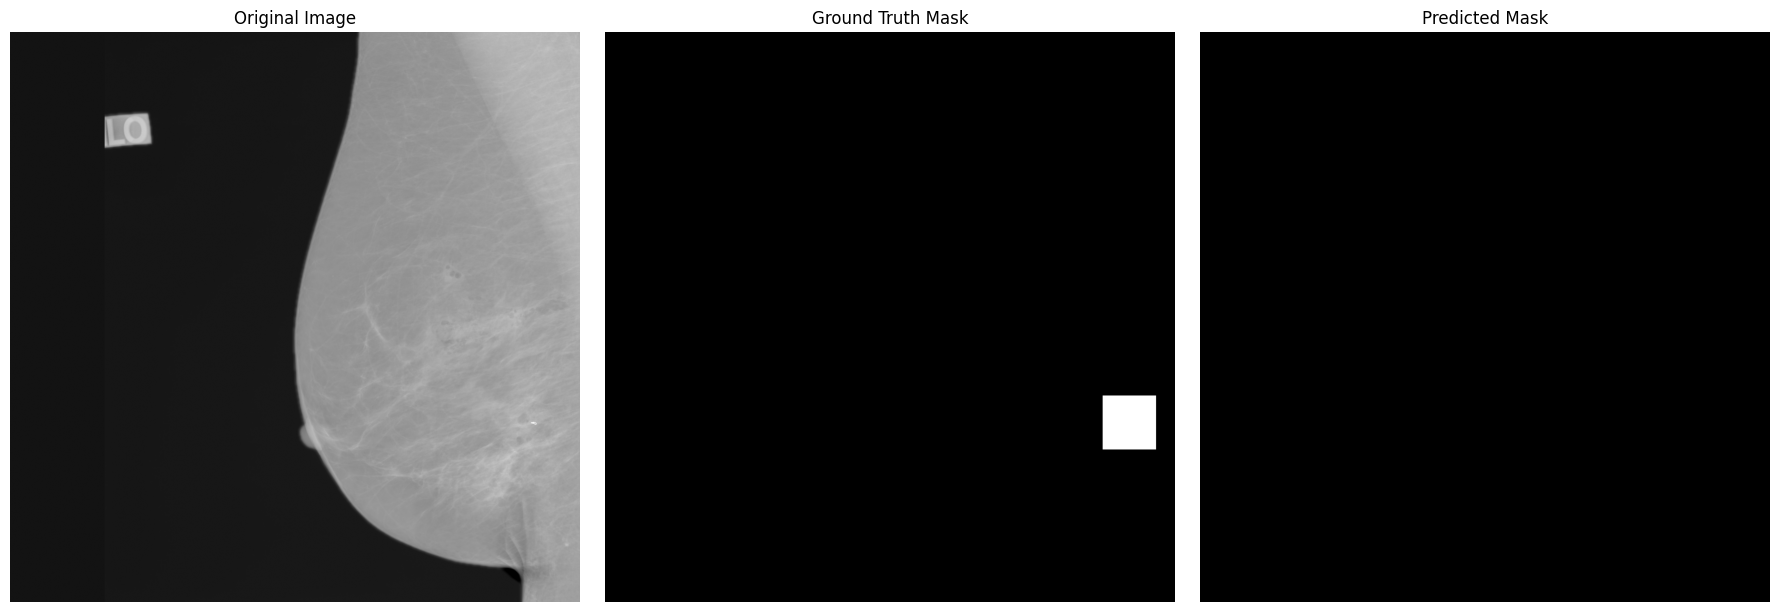

🔍 Image ID: 100949768998010865202496404359164471885 (Cancer)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


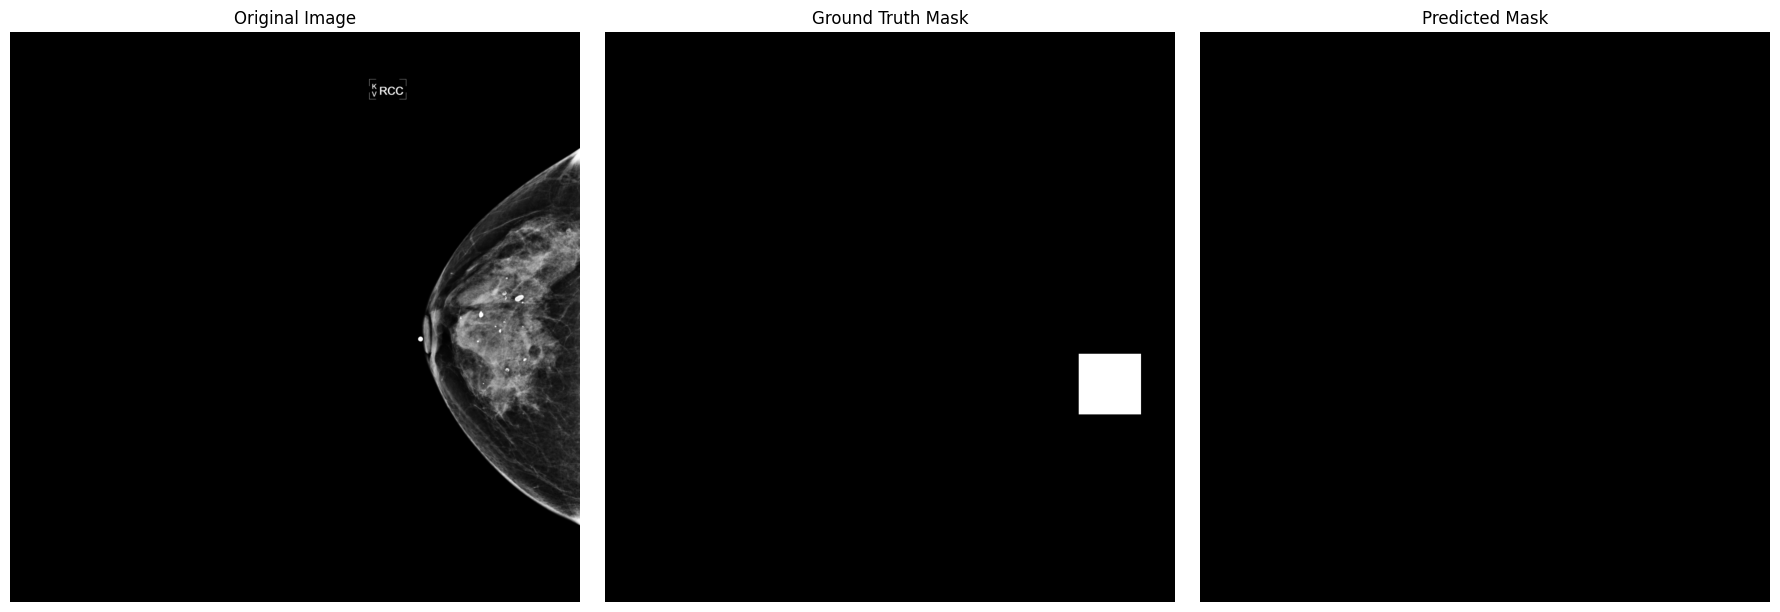

🔍 Image ID: 101095157148709686294400496431493272557 (Cancer)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


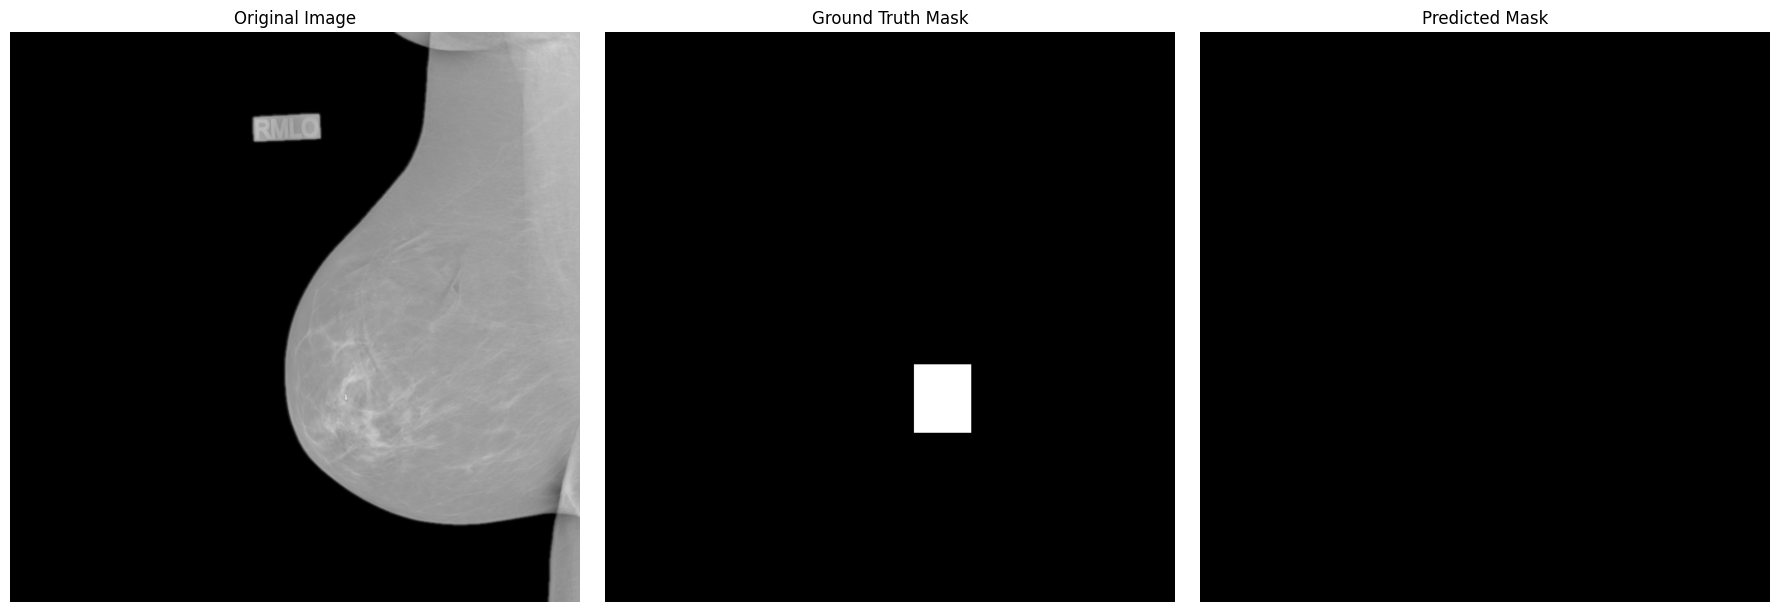

🔍 Image ID: 100059224779384444211358128421540348761 (Non-Cancer)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


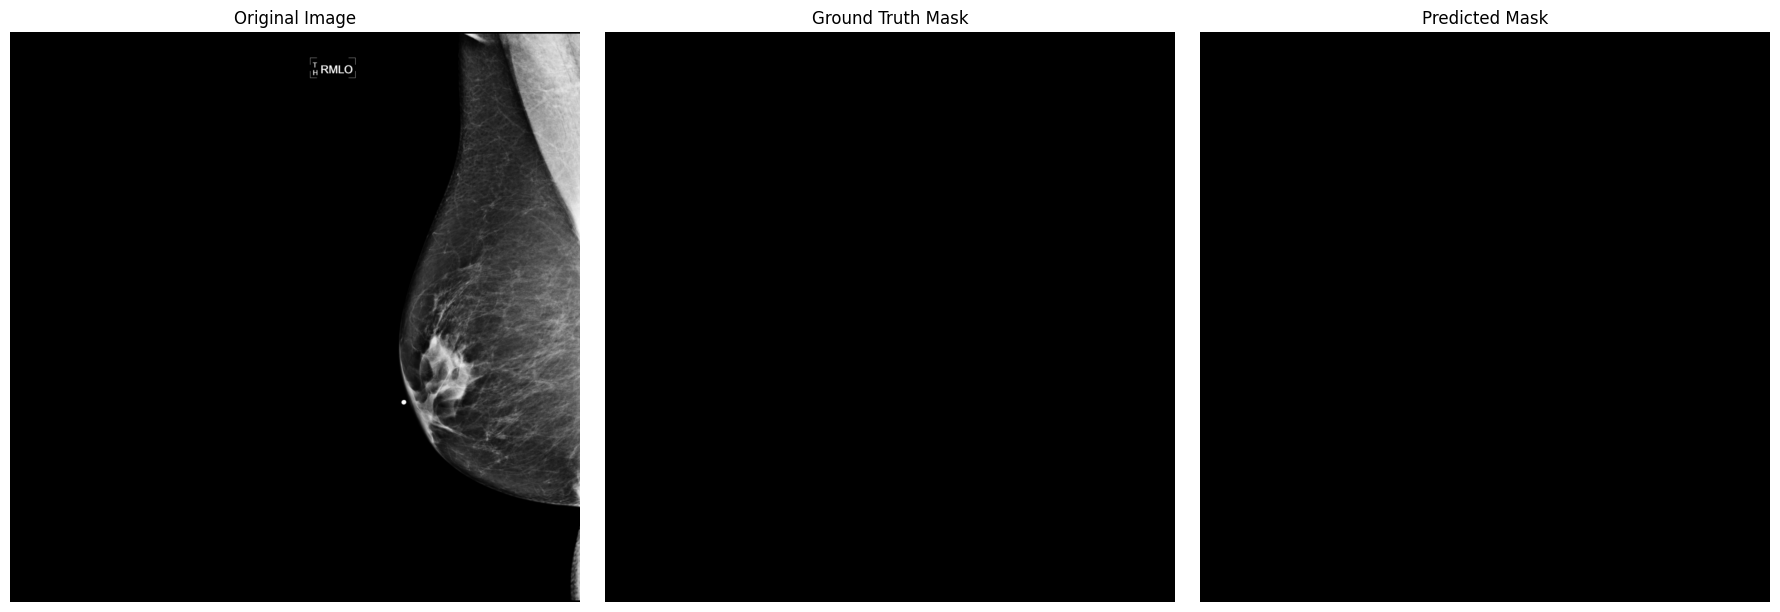

🔍 Image ID: 100079530485396036273000377554159041434 (Non-Cancer)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step


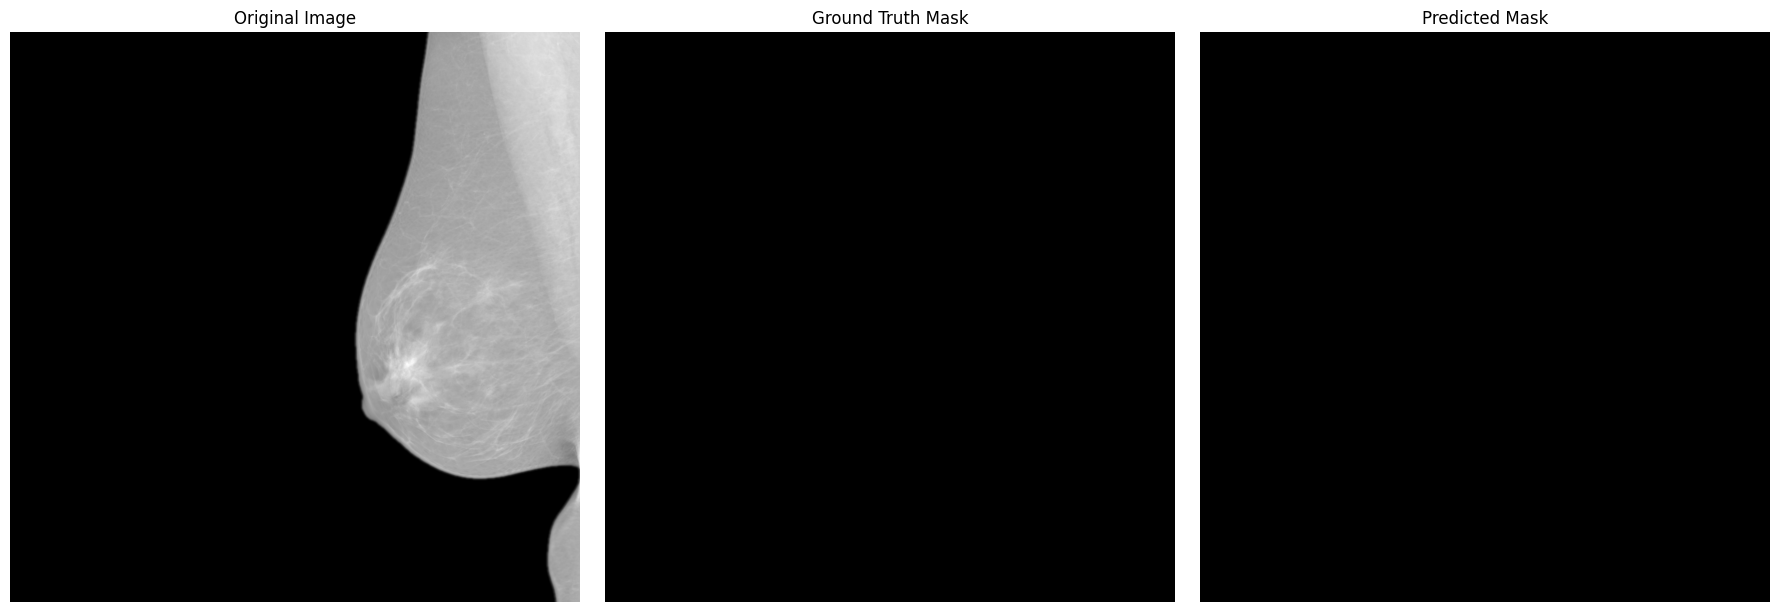

🔍 Image ID: 100123355944244842386723230867737643940 (Non-Cancer)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


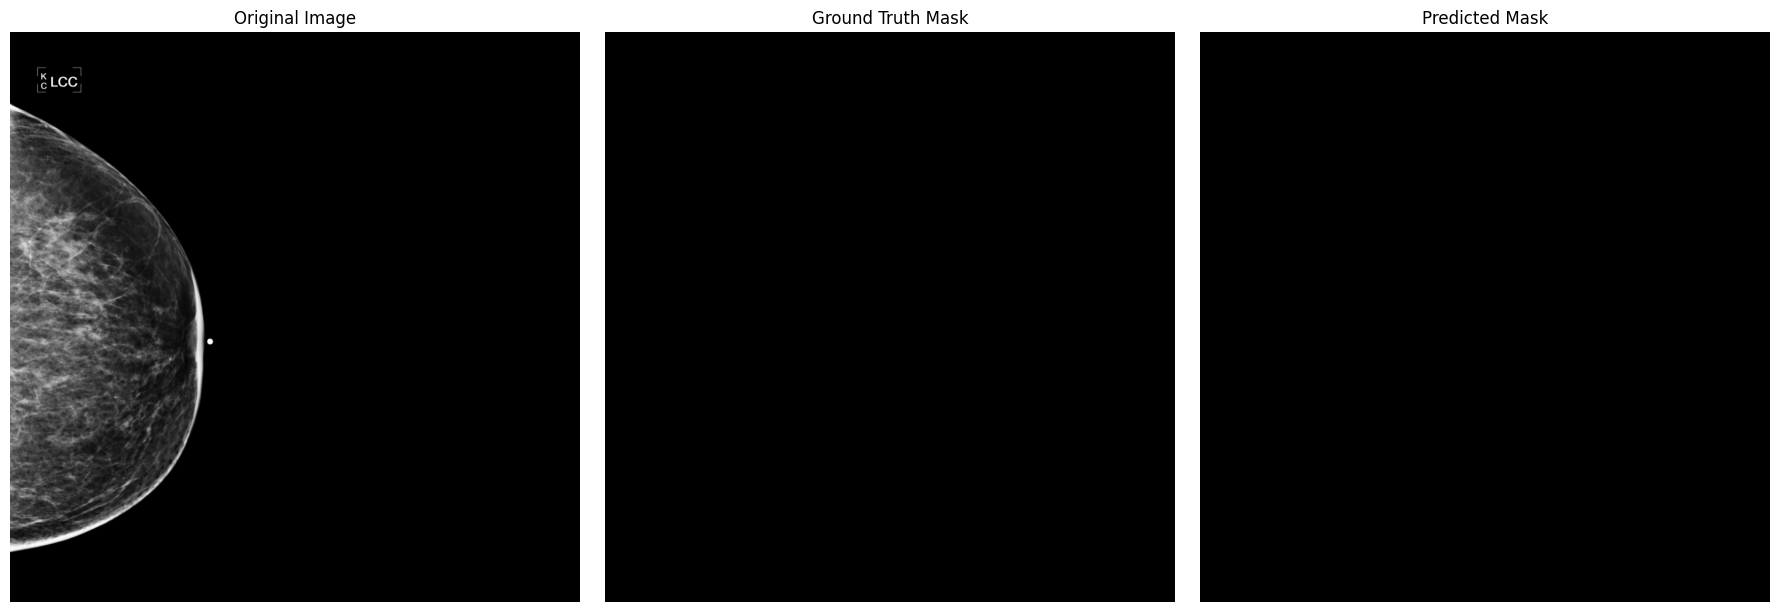

🔍 Image ID: 100202841031332486404628465057270871231 (Non-Cancer)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


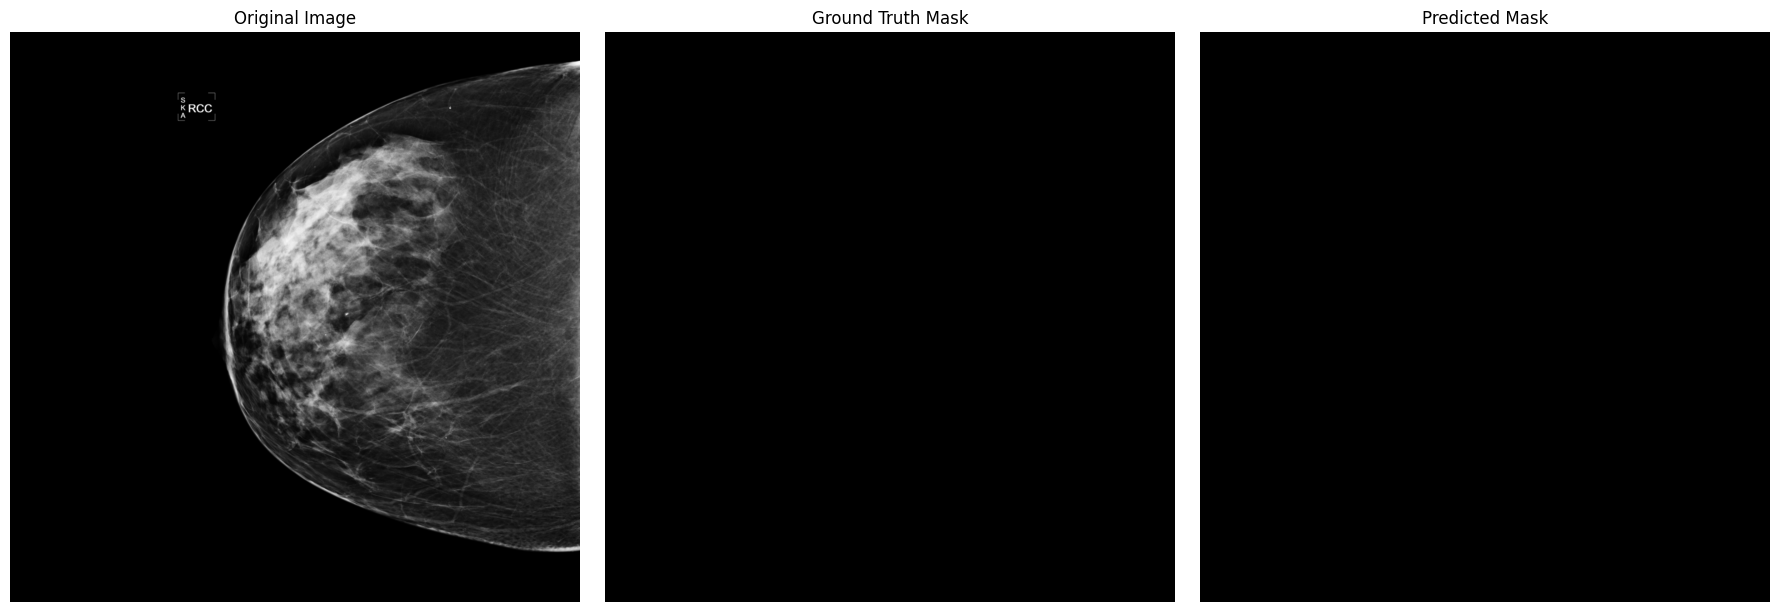

🔍 Image ID: 100251455879816274825030400384335709114 (Non-Cancer)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step


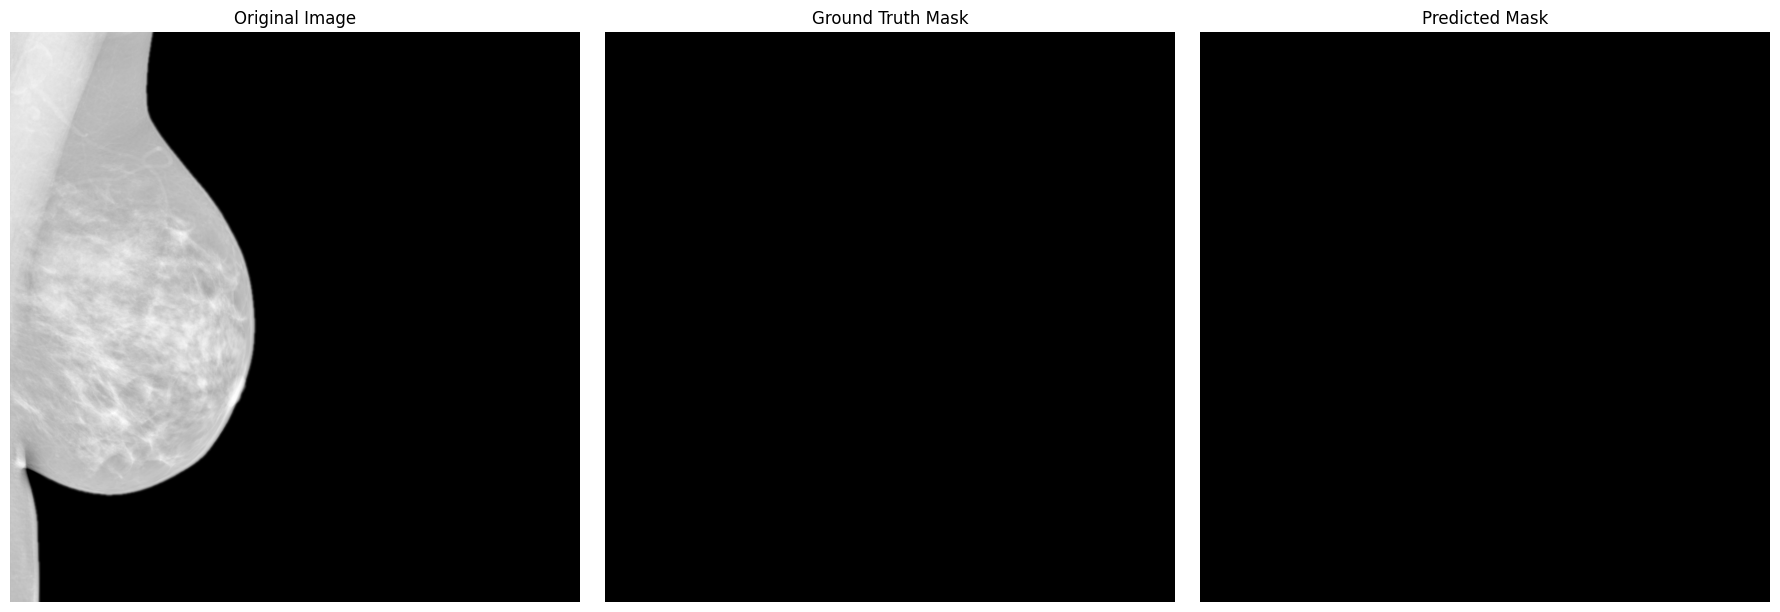

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
import tensorflow as tf
from tensorflow.keras.models import load_model

# Paths
MODEL_PATH = "/hpcstor6/scratch01/a/a.kanamarlapudi001/cancer_classifier_1024x1024/weights/cancer_focused_model.h5"
TEST_IMG_DIR = "/hpcstor6/scratch01/a/a.kanamarlapudi001/cancer_classifier_1024x1024/split/test/images"
TEST_MASK_DIR = "/hpcstor6/scratch01/a/a.kanamarlapudi001/cancer_classifier_1024x1024/split/test/masks"

# Load model
model = load_model(MODEL_PATH, compile=False)

# Helper functions
def load_image(image_id):
    path = os.path.join(TEST_IMG_DIR, image_id + ".npz")
    img = np.load(path)
    img = img[img.files[0]].astype(np.float32)
    img = (img - np.min(img)) / (np.max(img) - np.min(img))
    return np.expand_dims(img, axis=-1)

def load_mask(image_id):
    path = os.path.join(TEST_MASK_DIR, image_id + ".png")
    mask = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    mask = (mask > 127).astype(np.float32)
    return np.expand_dims(mask, axis=-1)

def visualize_prediction(image_id):
    image = load_image(image_id)
    mask = load_mask(image_id)
    pred = model.predict(np.expand_dims(image, axis=0))[0] > 0.5

    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    axs[0].imshow(image.squeeze(), cmap='gray')
    axs[0].set_title("Original Image")
    axs[1].imshow(mask.squeeze(), cmap='gray')
    axs[1].set_title("Ground Truth Mask")
    axs[2].imshow(pred.squeeze(), cmap='gray')
    axs[2].set_title("Predicted Mask")
    for ax in axs:
        ax.axis('off')
    plt.tight_layout()
    plt.show()

# Get image IDs
all_ids = sorted([f.replace(".npz", "") for f in os.listdir(TEST_IMG_DIR) if f.endswith(".npz")])
cancer_ids, non_cancer_ids = [], []

for img_id in all_ids:
    mask = load_mask(img_id)
    if np.sum(mask) > 0:
        cancer_ids.append(img_id)
    else:
        non_cancer_ids.append(img_id)

# Visualize first 5 cancer and 5 non-cancer images
for img_id in cancer_ids[:5] + non_cancer_ids[:5]:
    print(f"🔍 Image ID: {img_id} ({'Cancer' if img_id in cancer_ids else 'Non-Cancer'})")
    visualize_prediction(img_id)
